<a href="https://colab.research.google.com/github/akshatsharma-x/x-ray/blob/main/X_ray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2
import os
from tensorflow.keras.preprocessing import image
from google.colab import files


In [ ]:
train_dir = '/content/drive/My Drive/Bone/train/'
validation_dir = '/content/drive/My Drive/Bone/val/'

img_width, img_height = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=10,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)

class_indices = train_generator.class_indices
class_indices

Found 8890 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [ ]:
train_generator.filenames[:20]


['fractured/10-rotated1-rotated1-rotated1.jpg',
 'fractured/10-rotated1-rotated1-rotated2.jpg',
 'fractured/10-rotated1-rotated1-rotated3.jpg',
 'fractured/10-rotated1-rotated1.jpg',
 'fractured/10-rotated1-rotated2-rotated1.jpg',
 'fractured/10-rotated1-rotated2-rotated2.jpg',
 'fractured/10-rotated1-rotated2-rotated3.jpg',
 'fractured/10-rotated1-rotated2.jpg',
 'fractured/10-rotated1-rotated3-rotated1.jpg',
 'fractured/10-rotated1-rotated3-rotated2.jpg',
 'fractured/10-rotated1-rotated3-rotated3.jpg',
 'fractured/10-rotated1-rotated3.jpg',
 'fractured/10-rotated1.jpg',
 'fractured/10-rotated2-rotated1-rotated1.jpg',
 'fractured/10-rotated2-rotated1-rotated2.jpg',
 'fractured/10-rotated2-rotated1-rotated3.jpg',
 'fractured/10-rotated2-rotated1.jpg',
 'fractured/10-rotated2-rotated2-rotated1.jpg',
 'fractured/10-rotated2-rotated2-rotated2.jpg',
 'fractured/10-rotated2-rotated2-rotated3.jpg']

In [ ]:
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(224,224,3))

base_model.trainable = False

inputs = base_model.input
x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# import os
# from PIL import Image

# def remove_bad_images(directory):
#     bad_files = []
#     for root, _, files in os.walk(directory):
#         for f in files:
#             path = os.path.join(root, f)
#             try:
#                 img = Image.open(path)
#                 img.verify()
#             except Exception as e:
#                 bad_files.append(path)
#                 print("Removing bad file:", path)
#                 os.remove(path)
#     return bad_files

# train_bad = remove_bad_images(train_dir)
# val_bad = remove_bad_images(validation_dir)

# print("Bad files in train:", train_bad)
# print("Bad files in validation:", val_bad)


In [ ]:
model.compile(optimizer=optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 2196s 8s/step - accuracy: 0.6291 - loss: 0.6583 - val_accuracy: 0.7550 - val_loss: 0.5245
Epoch 2/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 489s 2s/step - accuracy: 0.7599 - loss: 0.4952 - val_accuracy: 0.7400 - val_loss: 0.5228
Epoch 3/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 485s 2s/step - accuracy: 0.8054 - loss: 0.4297 - val_accuracy: 0.7400 - val_loss: 0.4919
Epoch 4/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 509s 2s/step - accuracy: 0.8491 - loss: 0.3733 - val_accuracy: 0.7567 - val_loss: 0.4671
Epoch 5/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 512s 2s/step - accuracy: 0.8719 - loss: 0.3268 - val_accuracy: 0.7567 - val_loss: 0.4600


In [ ]:
base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True
model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning starting from layer:", fine_tune_at)

history_ft = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2
)


Fine-tuning starting from layer: 100
Epoch 1/2
278/278 ━━━━━━━━━━━━━━━━━━━━ 742s 3s/step - accuracy: 0.6979 - loss: 0.7070 - val_accuracy: 0.7050 - val_loss: 0.6302
Epoch 2/2
278/278 ━━━━━━━━━━━━━━━━━━━━ 737s 3s/step - accuracy: 0.8849 - loss: 0.2794 - val_accuracy: 0.7283 - val_loss: 0.6384


In [ ]:
loss, acc = model.evaluate(validation_generator)
print("Validation Accuracy:", acc)
print("Validation Loss:", loss)

validation_generator.reset()
y_pred = (model.predict(validation_generator) > 0.5).astype("int32")
y_true = validation_generator.classes

print(classification_report(y_true, y_pred))

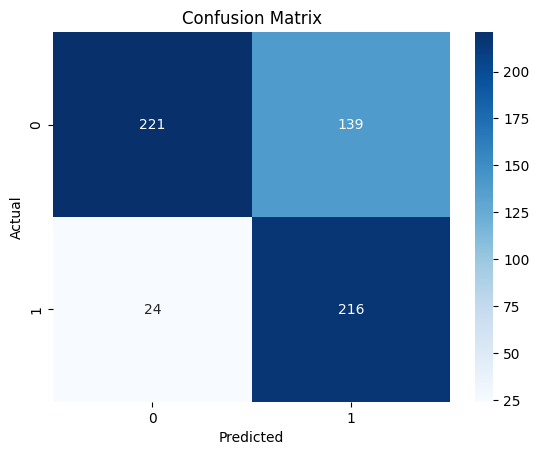

In [ ]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
def find_last_conv(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        if hasattr(layer, 'layers'):
            for sub in reversed(layer.layers):
                if isinstance(sub, tf.keras.layers.Conv2D):
                    return sub.name
    raise ValueError("No Conv2D layer found")

last_conv = find_last_conv(model)
print("Last Conv Layer:", last_conv)


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
from tensorflow.keras.models import Model

def find_last_conv_layer_obj(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer
        if hasattr(layer, "layers"):
            for sub in reversed(layer.layers):
                if isinstance(sub, tf.keras.layers.Conv2D):
                    return sub
    raise ValueError("No Conv2D layer found in model or its sublayers.")

def find_real_input_tensor(model):
    try:
        base = globals().get("base_model", None)
        if base is not None and hasattr(base, "input"):
            return base.input
    except Exception:
        pass

    try:
        return model.input
    except Exception:
        pass

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            return layer.output
    raise ValueError("Could not determine a valid input tensor for the model.")

def build_grad_model_for_gradcam(model):
    conv_layer_obj = find_last_conv_layer_obj(model)
    conv_layer_name = conv_layer_obj.name
    print("Detected last Conv2D layer object:", conv_layer_name)

    conv_output_tensor = conv_layer_obj.output

    real_input = find_real_input_tensor(model)
    print("Using input tensor:", real_input)

    grad_model = Model(inputs=real_input, outputs=[conv_output_tensor, model.output])
    return grad_model, conv_layer_name

grad_model, detected_conv_name = build_grad_model_for_gradcam(model)


Detected last Conv2D layer object: Conv_1
Using input tensor: <KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>


In [ ]:
def compute_gradcam_heatmap(img_array, grad_model, upsample_to=(224,224)):
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        score = preds[:, 0]
    grads = tape.gradient(score, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradients returned None — graph disconnected.")

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.zeros(conv_outputs.shape[0:2])
    for i in range(conv_outputs.shape[-1]):
        heatmap += pooled_grads[i] * conv_outputs[:,:,i]

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-10)
    heatmap = heatmap.numpy()
    heatmap = cv2.resize(heatmap, upsample_to)
    return np.clip(heatmap, 0, 1)


In [ ]:
def overlay_heatmap_on_image(img, heatmap, alpha=0.4):
    heatmap_uint8 = np.uint8(255 * heatmap)
    colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    img_uint8 = np.uint8(255 * img)
    overlay = cv2.addWeighted(colored, alpha, img_uint8, 1-alpha, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    return overlay


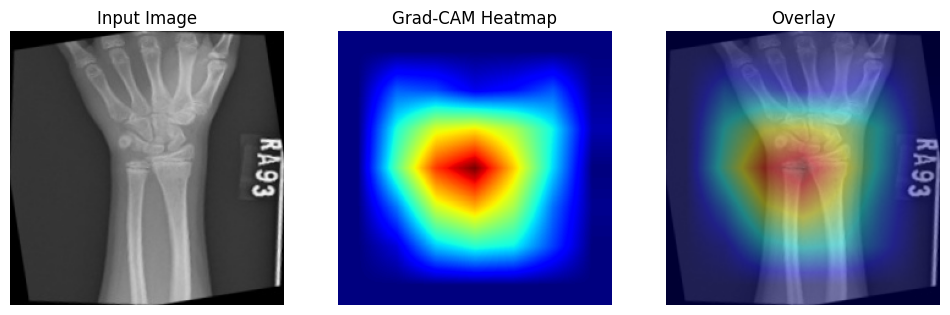

In [ ]:
imgs, lbls = next(validation_generator)

img = imgs[0]
true_label = lbls[0]

x = np.expand_dims(img, axis=0)

heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
overlay = overlay_heatmap_on_image(img, heatmap)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Input Image"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(heatmap, cmap='jet'); plt.title("Grad-CAM Heatmap"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay"); plt.axis('off')
plt.show()


In [ ]:
def predict_and_gradcam(img, grad_model, model):
    x = np.expand_dims(img, axis=0)
    pred_prob = model.predict(x)[0][0]
    pred_label = "FRACTURED" if pred_prob > 0.5 else "NORMAL"

    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    plt.figure(figsize=(14,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Input X-ray"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(heatmap, cmap='jet'); plt.title("Grad-CAM Heatmap"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(overlay);
    plt.title(f"Overlay\nPrediction: {pred_label}\nConfidence: {pred_prob:.3f}")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


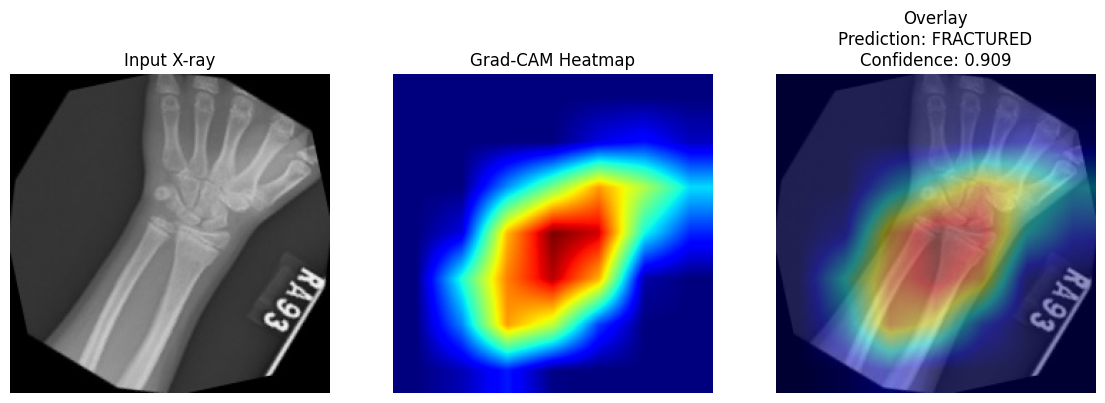

In [ ]:
imgs, lbls = next(validation_generator)
predict_and_gradcam(imgs[0], grad_model, model)


In [ ]:
def full_diagnostic_panel(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    prob = float(model.predict(x)[0][0])
    pred_label = "FRACTURED" if prob > 0.5 else "NORMAL"

    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig, axes = plt.subplots(2, 2, figsize=(12,10))

    axes[0,0].imshow(img)
    axes[0,0].set_title("Original X-ray")
    axes[0,0].axis('off')

    axes[0,1].imshow(heatmap, cmap='inferno')
    axes[0,1].set_title("Grad-CAM Heatmap")
    axes[0,1].axis('off')

    axes[1,0].imshow(overlay)
    axes[1,0].set_title("Heatmap Overlay")
    axes[1,0].axis('off')

    axes[1,1].bar(["Normal", "Fractured"], [1-prob, prob], color=["green", "red"])
    axes[1,1].set_ylim([0,1])
    axes[1,1].set_title("Prediction Probabilities")
    axes[1,1].set_ylabel("Probability")

    plt.suptitle(f"Prediction: {pred_label} ({prob:.3f})", fontsize=16)
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


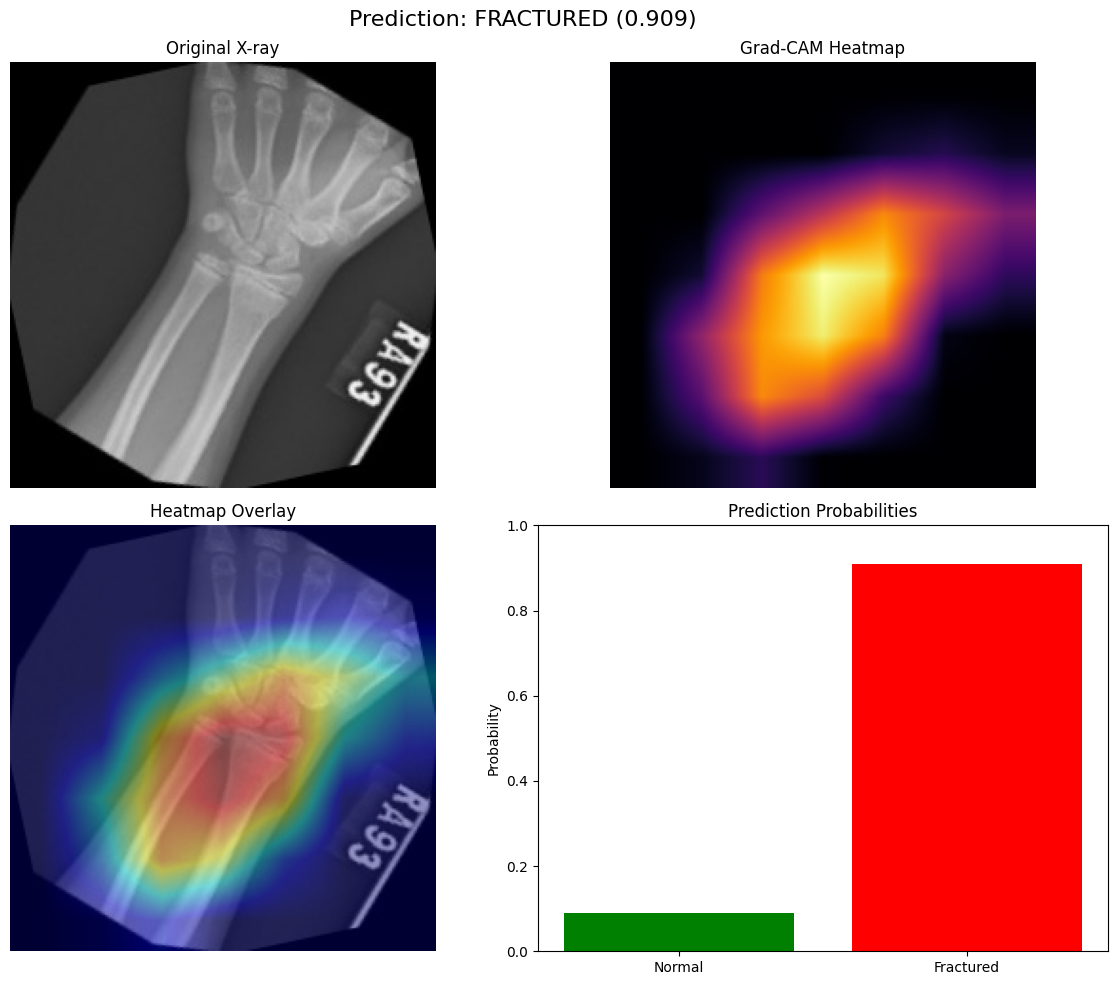

In [ ]:
full_diagnostic_panel(imgs[0], model, grad_model)


In [ ]:
def gradcam_grid(images, grad_model, model, rows=2, cols=4):
    plt.figure(figsize=(16,8))
    for i in range(rows*cols):
        img = images[i]
        x = np.expand_dims(img, axis=0)
        heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
        overlay = overlay_heatmap_on_image(img, heatmap)

        plt.subplot(rows, cols, i+1)
        plt.imshow(overlay)
        plt.axis('off')
        plt.title(f"Image {i+1}")

    plt.suptitle("Grad-CAM Overlay Grid", fontsize=18)
    plt.tight_layout()
    plt.show()


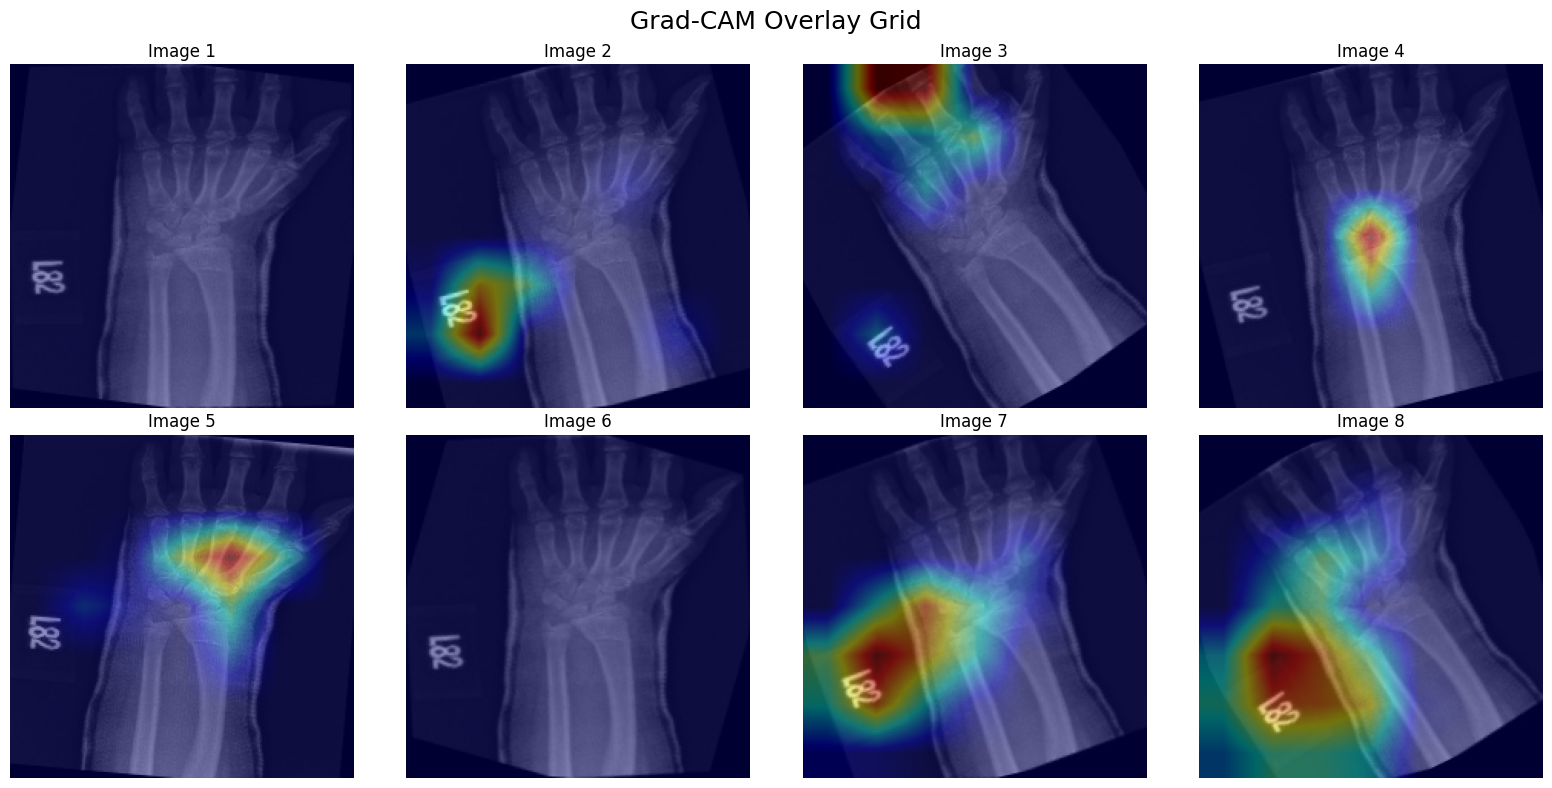

In [ ]:
imgs, lbls = next(validation_generator)
gradcam_grid(imgs, grad_model, model)


In [ ]:
import os

def save_gradcam_batch(images, output_folder="gradcam_outputs"):
    os.makedirs(output_folder, exist_ok=True)

    for idx, img in enumerate(images):
        x = np.expand_dims(img, axis=0)
        heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
        overlay = overlay_heatmap_on_image(img, heatmap)

        cv2.imwrite(f"{output_folder}/gradcam_{idx}.jpg", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    print(f"Saved {len(images)} Grad-CAM images to {output_folder}/")


In [ ]:
save_gradcam_batch(imgs)


Saved 32 Grad-CAM images to gradcam_outputs/


In [ ]:
def gradcam_filmstrip(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig = plt.figure(figsize=(12,4))

    titles = ["Input", "Grad-CAM", "Overlay"]
    imgs_plot = [img, heatmap, overlay]

    for i in range(3):
        ax = fig.add_subplot(1,3,i+1)
        ax.imshow(imgs_plot[i], cmap=None if i!=1 else 'jet')
        ax.axis("off")
        ax.set_title(titles[i])

    plt.tight_layout()
    plt.show()


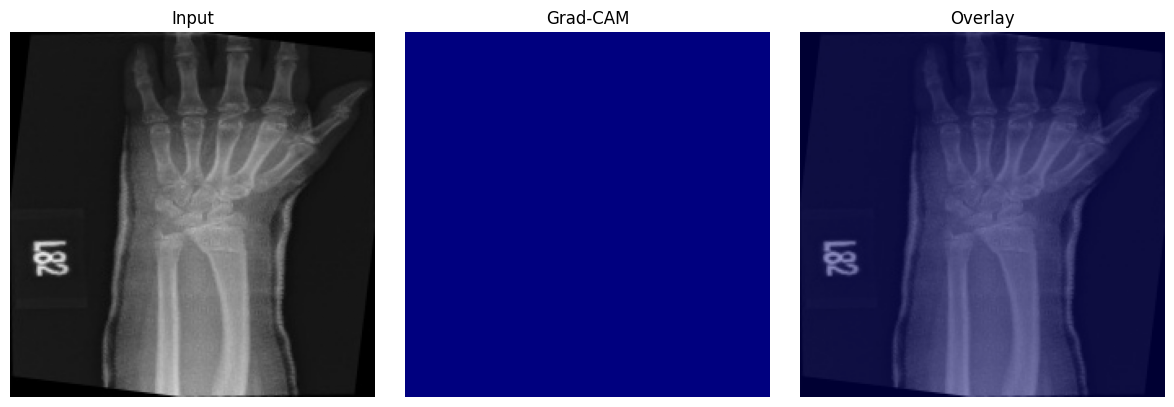

In [ ]:
gradcam_filmstrip(imgs[0], model, grad_model)


In [ ]:
def prediction_bar_with_gradcam(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    prob = model.predict(x)[0][0]
    pred_label = "Fractured" if prob > 0.5 else "Normal"

    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig = plt.figure(figsize=(14,6))

    ax1 = fig.add_subplot(1,2,1)
    ax1.imshow(overlay)
    ax1.set_title(f"Prediction: {pred_label}")
    ax1.axis("off")

    ax2 = fig.add_subplot(1,2,2)
    ax2.bar(["Normal", "Fractured"], [1-prob, prob], color=["green", "crimson"])
    ax2.set_ylim(0,1)
    ax2.set_title("Prediction Confidence")
    ax2.set_ylabel("Probability")

    plt.tight_layout()
    plt.show()


In [ ]:
def clinical_gradcam(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig, axs = plt.subplots(1, 2, figsize=(12,5), facecolor='black')

    axs[0].imshow(img)
    axs[0].set_title("Original", color='white')
    axs[0].axis('off')

    axs[1].imshow(overlay)
    axs[1].set_title("Grad-CAM Overlay", color='white')
    axs[1].axis('off')

    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


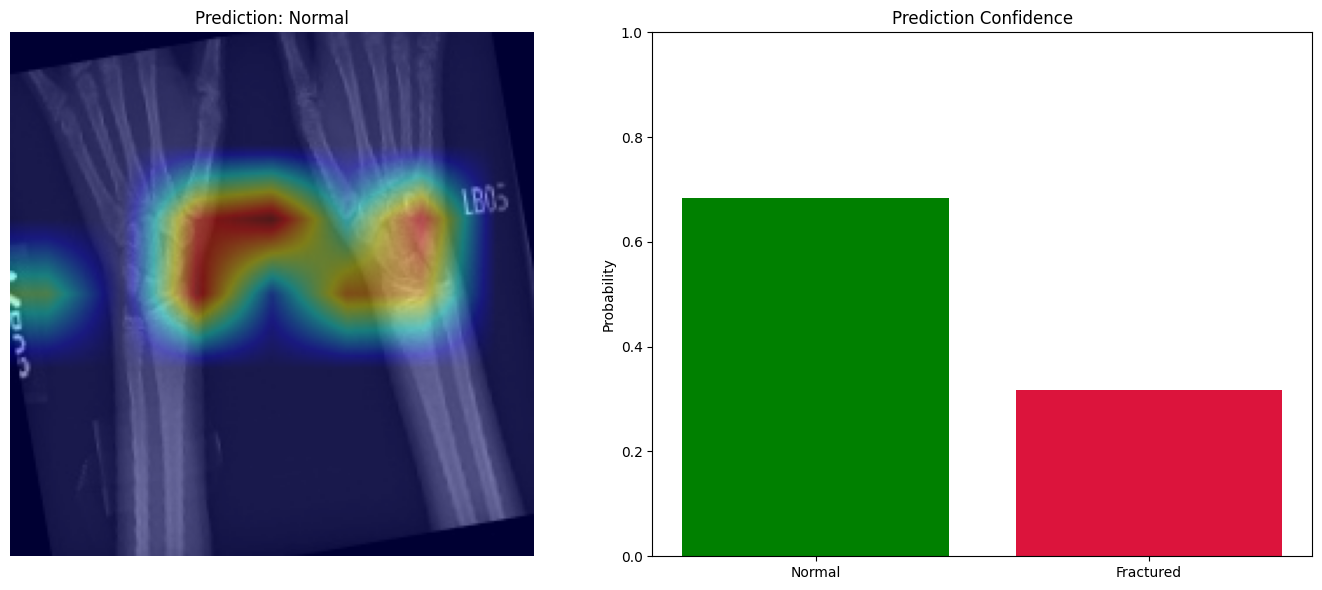

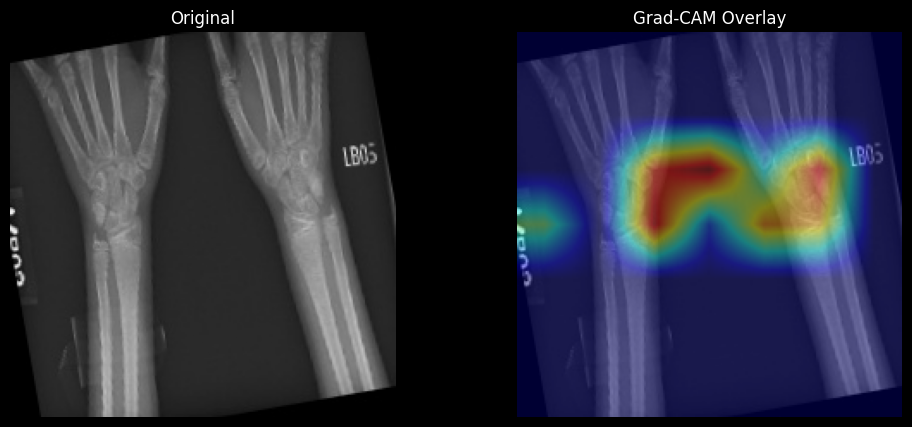

In [ ]:
imgs, lbls = next(validation_generator)

img = imgs[0]

prediction_bar_with_gradcam(img, model, grad_model)

clinical_gradcam(img, model, grad_model)


---- Image 0 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


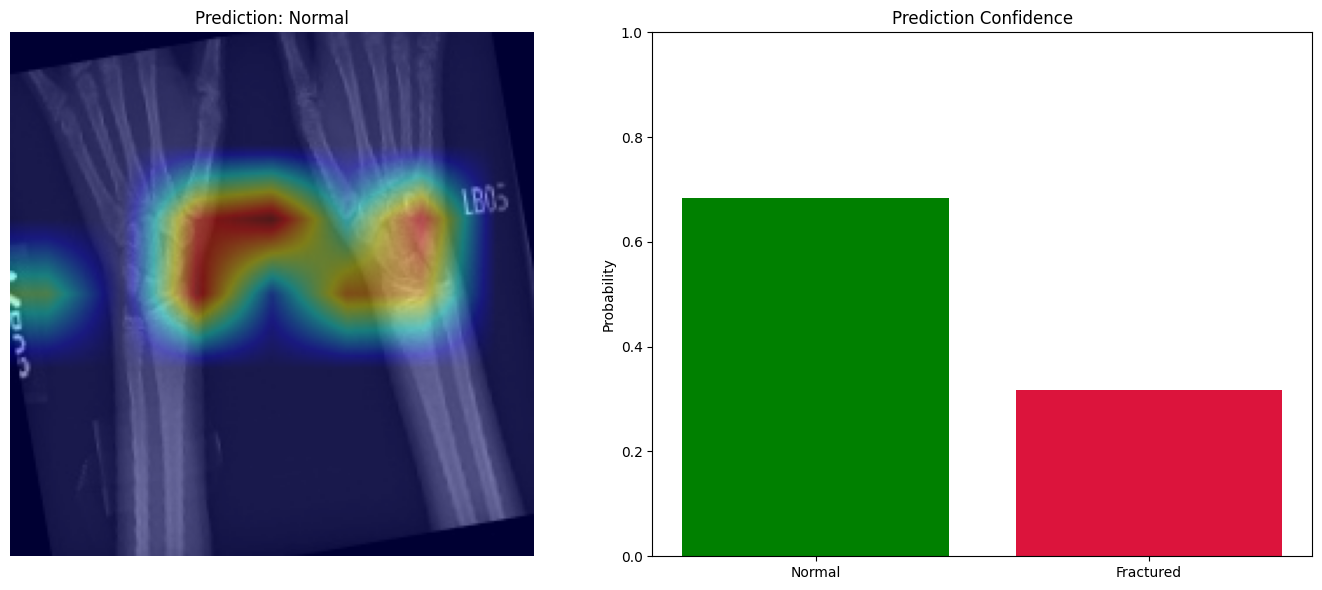

---- Image 1 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


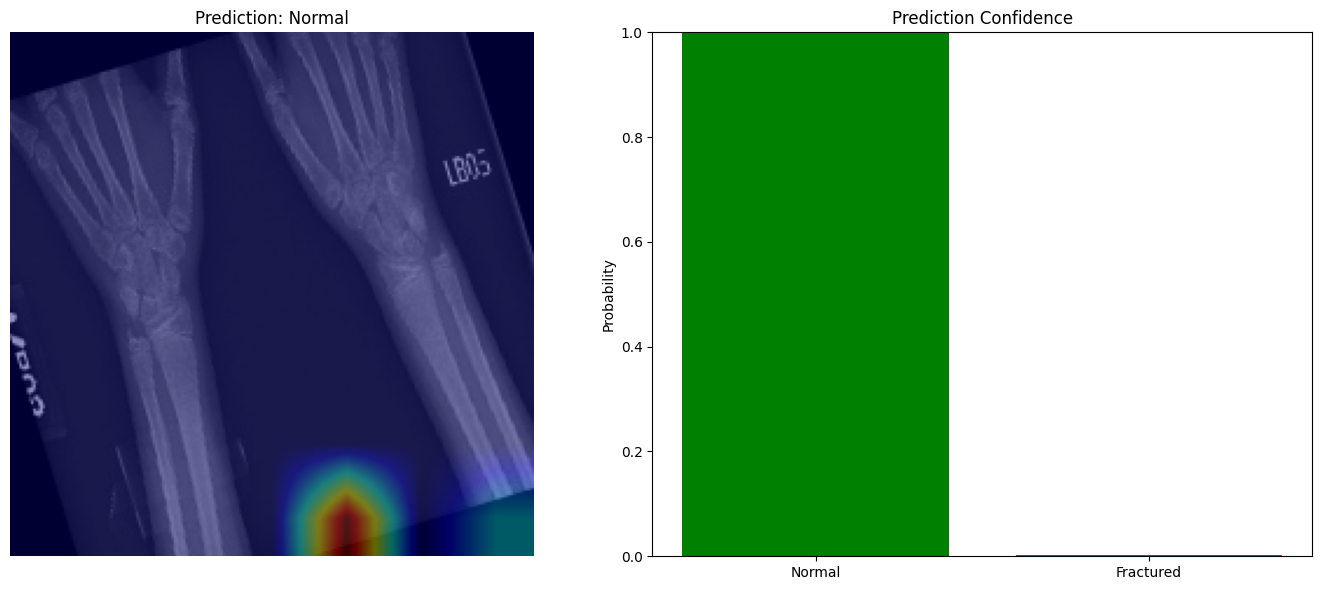

---- Image 2 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


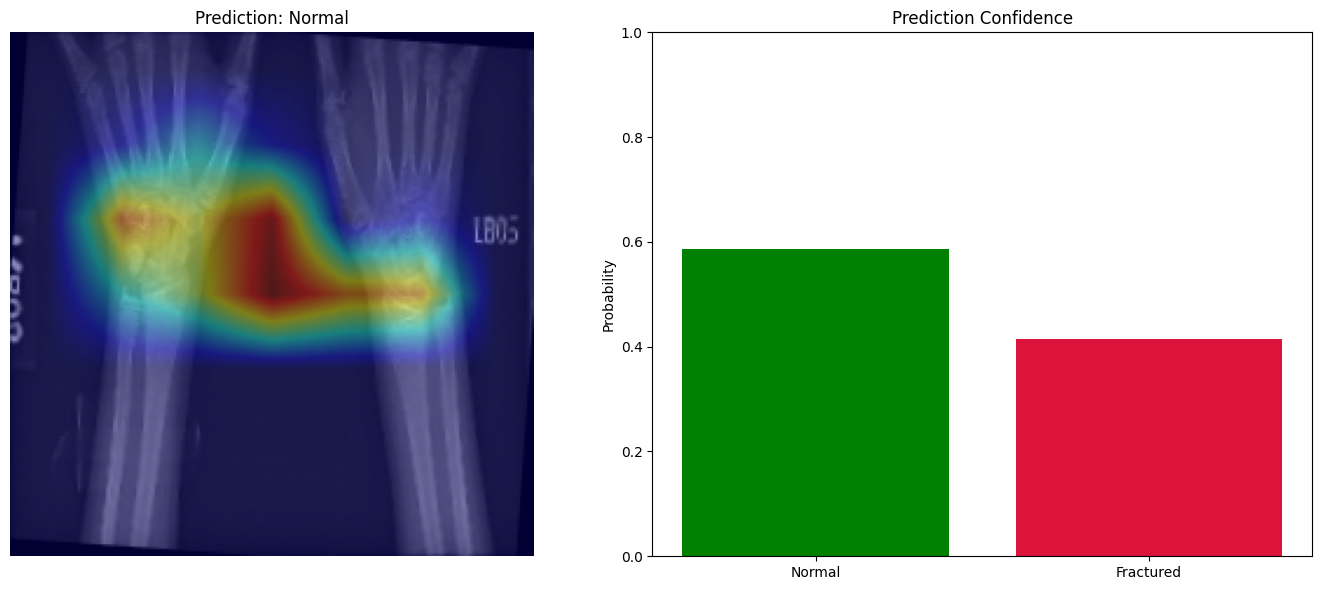

---- Image 3 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


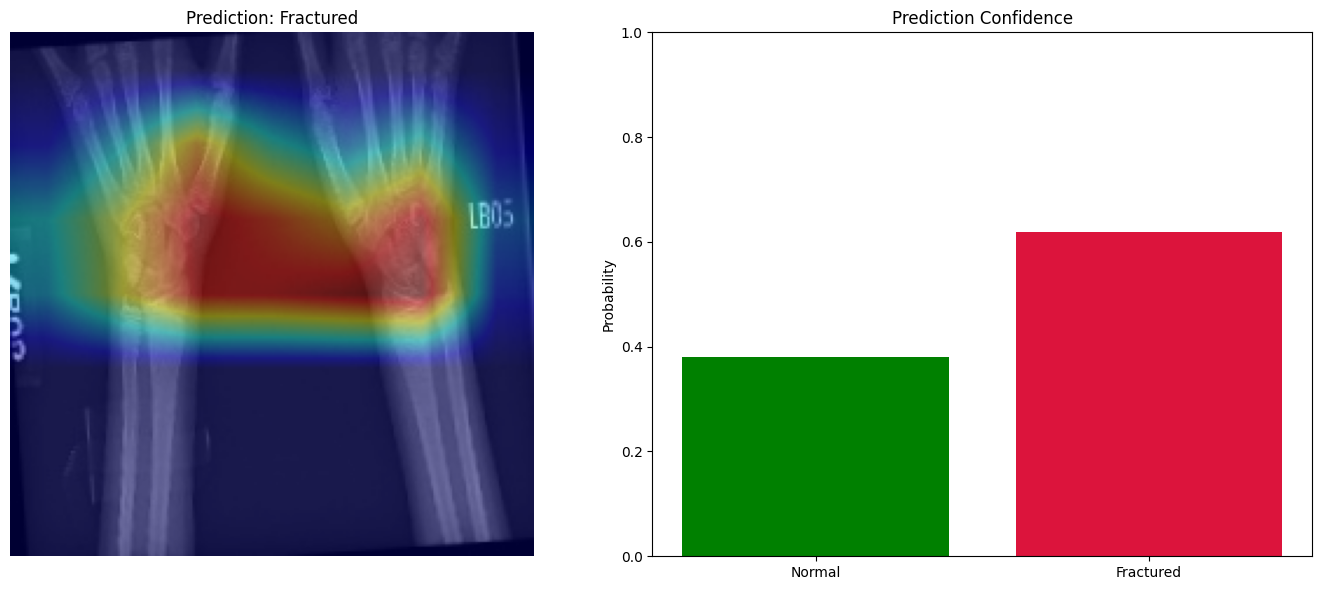

---- Image 4 ----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


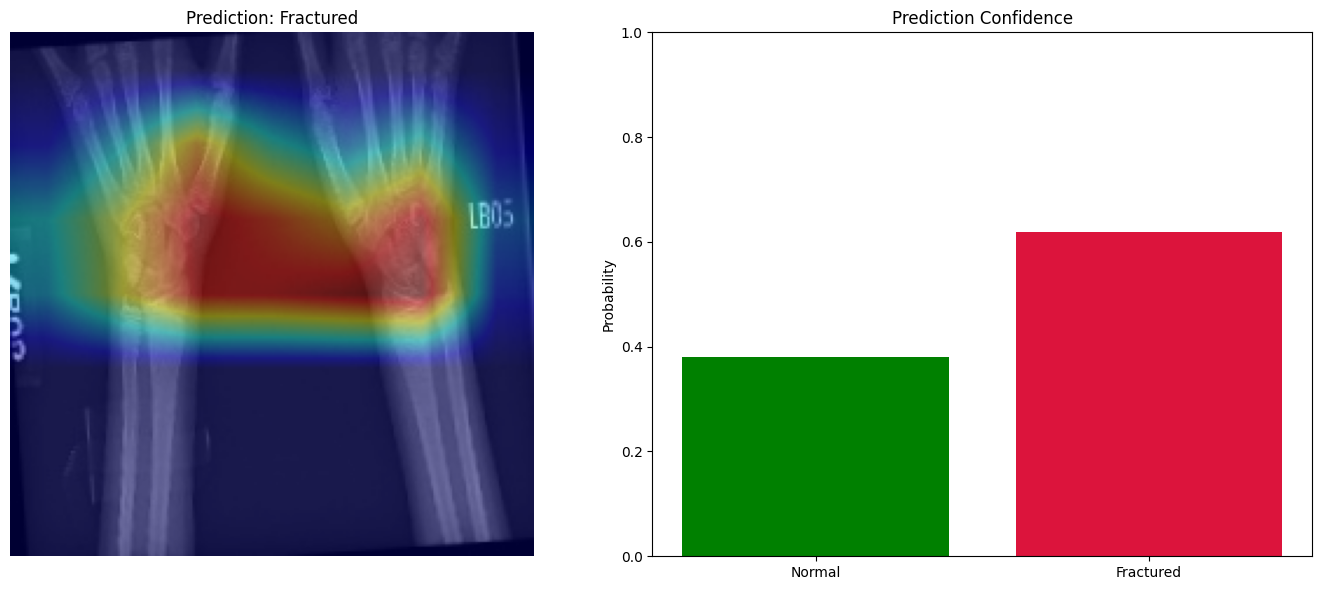

In [ ]:
for i in range(5):
    print(f"---- Image {i} ----")
    prediction_bar_with_gradcam(imgs[i], model, grad_model)


In [ ]:
def advanced_probability_bar(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    prob = float(model.predict(x)[0][0])

    fig, ax = plt.subplots(figsize=(8,4))

    bars = ax.bar(["Normal", "Fractured"], [1-prob, prob],
                  color=["#4CAF50", "#C62828"], edgecolor="black")

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0,1)
    ax.set_ylabel("Probability")
    ax.set_title("Prediction Confidence (with Value Labels)", fontsize=14)
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


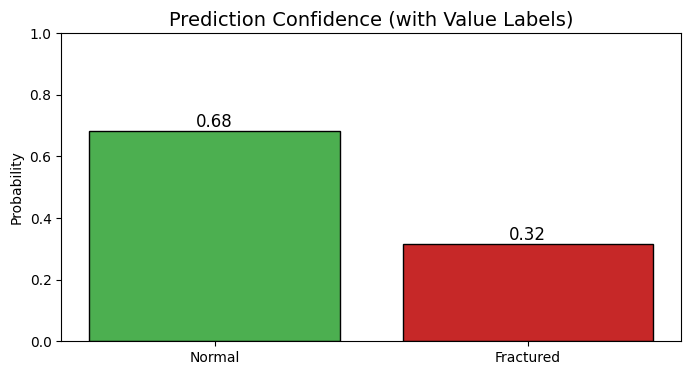

In [ ]:
advanced_probability_bar(imgs[0], model, grad_model)


In [ ]:
def radar_chart_prediction(img, model):
    x = np.expand_dims(img, axis=0)
    prob = float(model.predict(x)[0][0])

    categories = ["Normal", "Fractured"]
    values = [1-prob, prob]

    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.3)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title("Prediction Radar Chart", fontsize=14)

    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


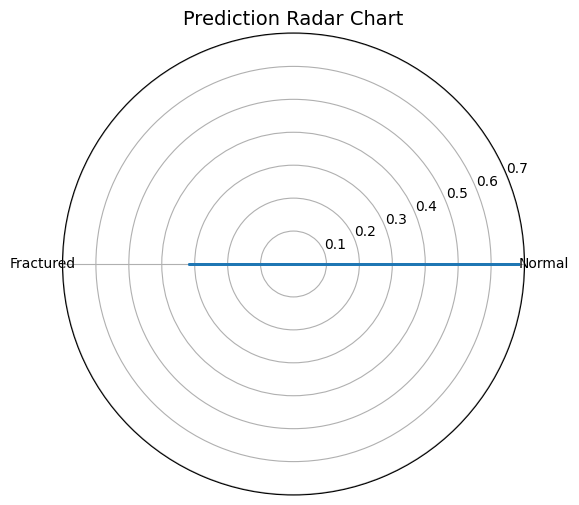

In [ ]:
radar_chart_prediction(imgs[0], model)


In [ ]:
def multi_intensity_gradcam(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))

    fig, axs = plt.subplots(1, 3, figsize=(15,5))
    alphas = [0.3, 0.5, 0.7]

    for i, alpha in enumerate(alphas):
        overlay = overlay_heatmap_on_image(img, heatmap, alpha)
        axs[i].imshow(overlay)
        axs[i].set_title(f"α = {alpha}")
        axs[i].axis('off')

    plt.suptitle("Multi-Intensity Grad-CAM Views", fontsize=16)
    plt.show()


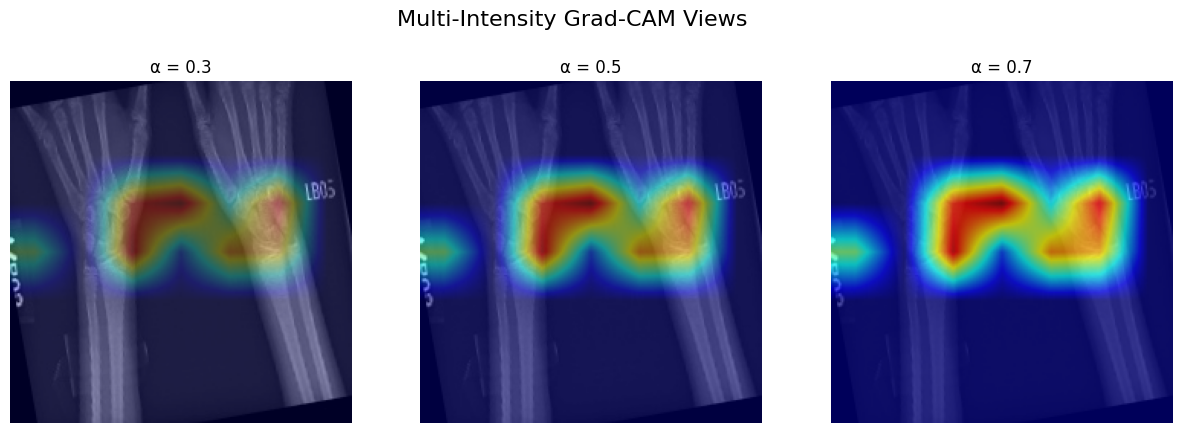

In [ ]:
multi_intensity_gradcam(imgs[0], model, grad_model)


In [ ]:
def prediction_trend_plot(validation_generator, model, num_samples=30):
    imgs, lbls = next(validation_generator)
    imgs = imgs[:num_samples]

    preds = model.predict(imgs).flatten()

    plt.figure(figsize=(10,4))
    plt.plot(preds, marker='o', linewidth=2)
    plt.ylim(0,1)
    plt.xlabel("Sample Index")
    plt.ylabel("Fracture Probability")
    plt.title("Prediction Trend Across Samples")
    plt.grid(True)
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


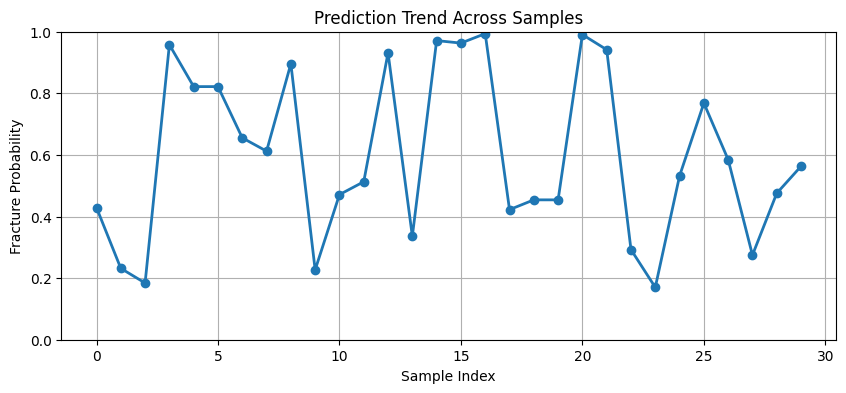

In [ ]:
prediction_trend_plot(validation_generator, model)


In [ ]:
def full_advanced_panel(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    prob = float(model.predict(x)[0][0])

    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig = plt.figure(figsize=(15,8))

    ax1 = fig.add_subplot(2,2,1)
    ax1.imshow(overlay)
    ax1.set_title("Grad-CAM Overlay")
    ax1.axis("off")

    ax2 = fig.add_subplot(2,2,2)
    ax2.imshow(heatmap, cmap="inferno")
    ax2.set_title("Heatmap Only")
    ax2.axis("off")

    ax3 = fig.add_subplot(2,2,3)
    ax3.bar(["Normal", "Fractured"], [1-prob, prob],
            color=["green", "crimson"])
    ax3.set_ylim(0,1)
    ax3.set_title("Prediction Probability")

    categories = ["Normal", "Fractured"]
    angles = np.linspace(0, 2 * np.pi, 2, endpoint=False).tolist()
    rad_vals = [1-prob, prob, 1-prob]
    angles += angles[:1]

    ax4 = fig.add_subplot(2,2,4, polar=True)
    ax4.plot(angles, rad_vals, linewidth=2)
    ax4.fill(angles, rad_vals, alpha=0.3)
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(categories)
    ax4.set_title("Radar Confidence Map")

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


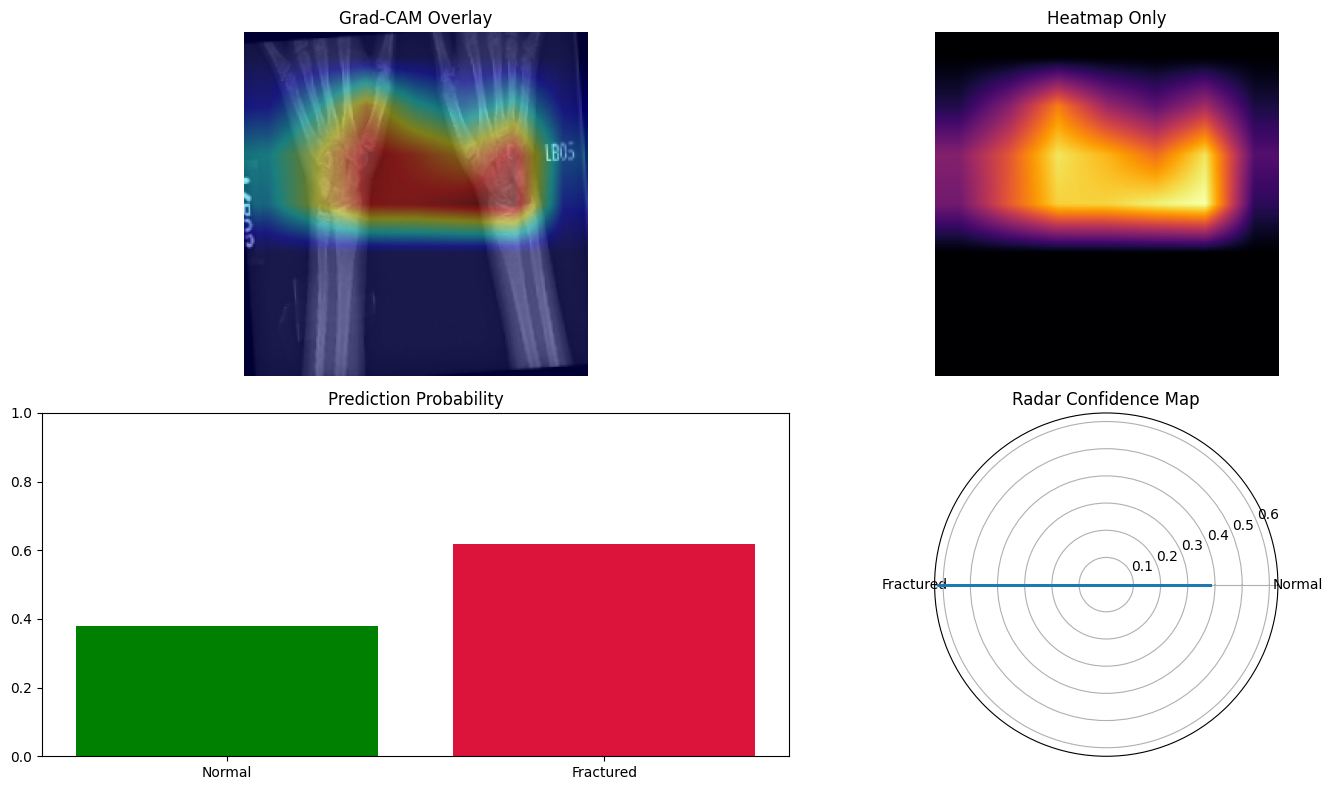

In [ ]:
full_advanced_panel(imgs[4], model, grad_model)


In [ ]:
def medical_journal_composite(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    prob = float(model.predict(x)[0][0])

    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig = plt.figure(figsize=(18,6), facecolor='white')

    ax1 = fig.add_subplot(1,3,1)
    ax1.imshow(img)
    ax1.set_title("A. Original X-ray", fontsize=14)
    ax1.axis('off')

    ax2 = fig.add_subplot(1,3,2)
    ax2.imshow(overlay)
    ax2.set_title("B. Grad-CAM Overlay", fontsize=14)
    ax2.axis('off')

    ax3 = fig.add_subplot(1,3,3)
    ax3.bar(["Normal", "Fractured"], [1-prob, prob], color=["#2E7D32","#B71C1C"])
    ax3.set_ylim(0, 1)
    ax3.set_title("C. Model Confidence", fontsize=14)
    ax3.set_ylabel("Probability")

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


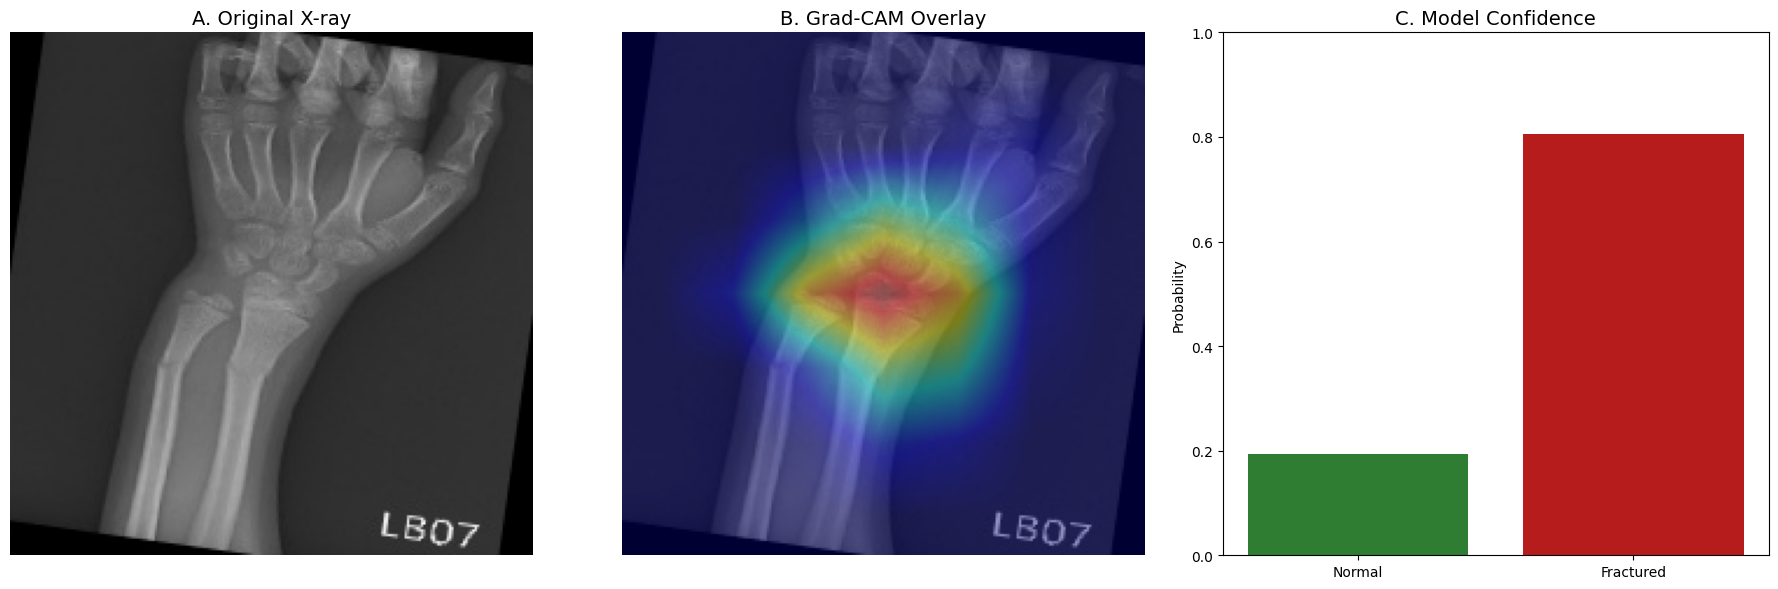

In [ ]:
imgs, lbls = next(validation_generator)

img = imgs[2]

medical_journal_composite(img, model, grad_model)


In [ ]:
def radiologist_quad_panel(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    gray = cv2.cvtColor(np.uint8(img*255), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    fig = plt.figure(figsize=(16,8))

    panels = [
        ("A. Original X-ray", img),
        ("B. Grad-CAM Heatmap", heatmap),
        ("C. Edge-enhanced Fracture Map", edges),
        ("D. Overlay Image", overlay)
    ]

    for i,(title,data) in enumerate(panels):
        ax = fig.add_subplot(2,2,i+1)
        cmap = None if i in [0,3] else "jet"
        ax.imshow(data, cmap=cmap)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


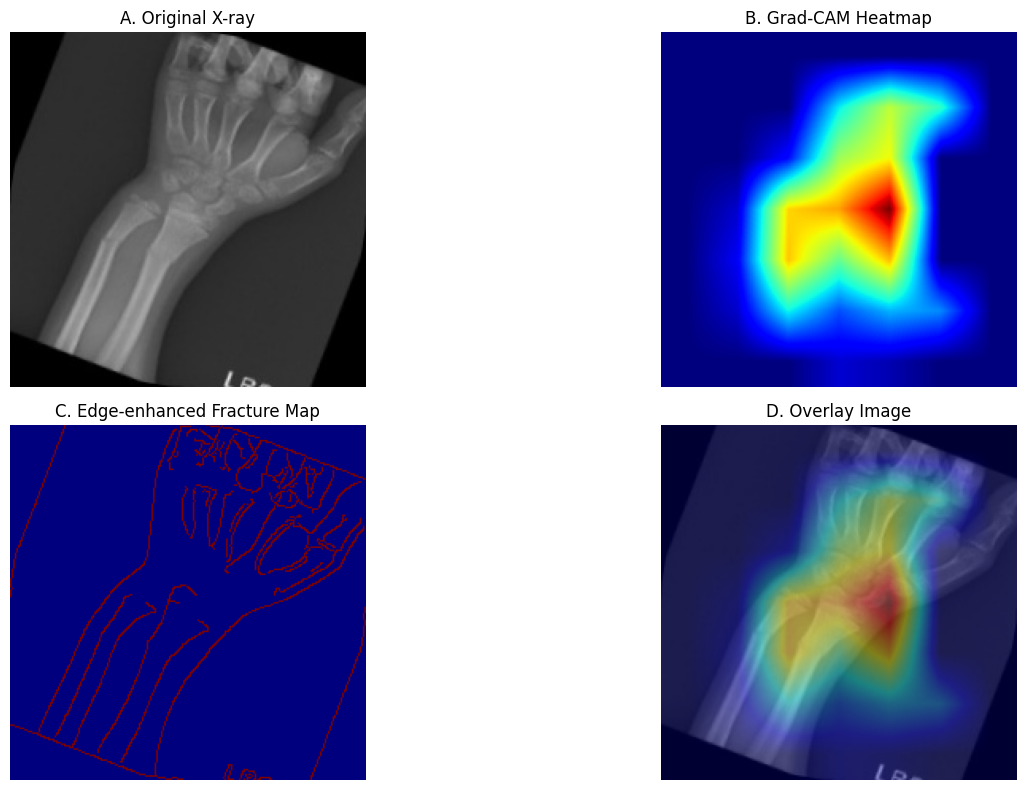

In [ ]:
radiologist_quad_panel(imgs[0], model, grad_model)


In [ ]:
def thermal_gradcam(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))

    heatmap_uint8 = np.uint8(255 * heatmap)
    thermal = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_HOT)
    thermal = cv2.cvtColor(thermal, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7,7))
    plt.imshow(thermal)
    plt.title("Thermal Medical Grad-CAM", fontsize=14)
    plt.axis("off")
    plt.show()


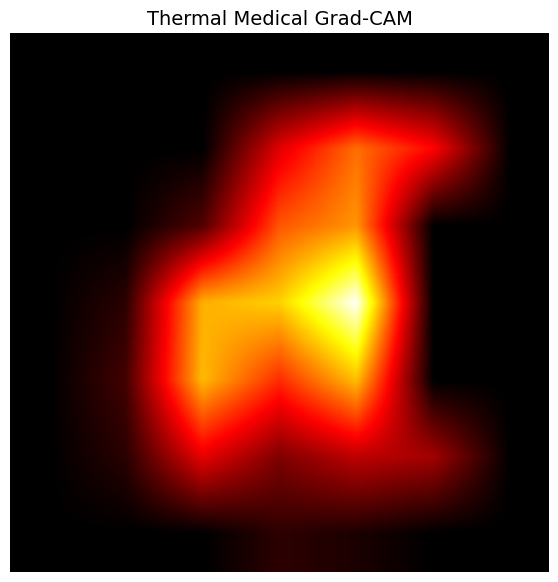

In [ ]:
thermal_gradcam(imgs[0], model, grad_model)


In [ ]:
def clinical_strip(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig, ax = plt.subplots(1, 3, figsize=(18,6))

    images = [img, heatmap, overlay]
    titles = ["Original", "Grad-CAM", "Overlay"]

    for i in range(3):
        ax[i].imshow(images[i], cmap="inferno" if i==1 else None)
        ax[i].set_title(titles[i], fontsize=15)
        ax[i].axis('off')

    plt.show()


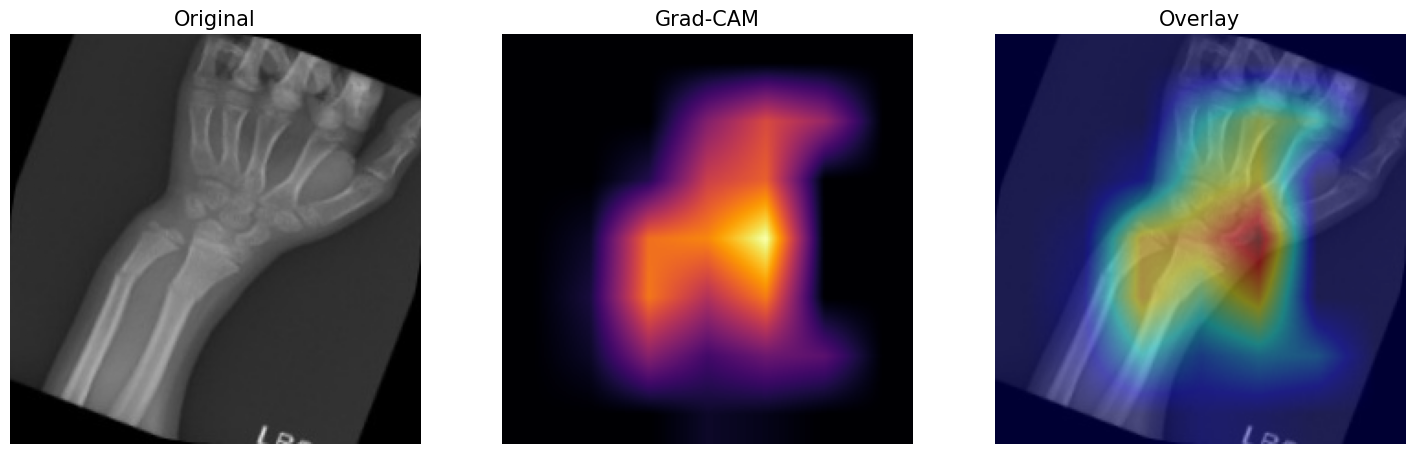

In [ ]:
clinical_strip(imgs[0], model, grad_model)


In [ ]:
def zoomed_gradcam(img, model, grad_model, zoom=2):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    y, x_coord = np.unravel_index(np.argmax(heatmap), heatmap.shape)

    h, w = img.shape[:2]
    size = min(h,w) // zoom

    x1 = max(0, x_coord - size)
    y1 = max(0, y - size)
    x2 = min(w, x_coord + size)
    y2 = min(h, y + size)

    zoom_crop = overlay[y1:y2, x1:x2]

    fig, ax = plt.subplots(1,2, figsize=(14,6))
    ax[0].imshow(overlay)
    ax[0].set_title("Full Overlay", fontsize=14)
    ax[0].axis("off")

    ax[1].imshow(zoom_crop)
    ax[1].set_title("Zoomed-in Fracture Region", fontsize=14)
    ax[1].axis("off")

    plt.show()


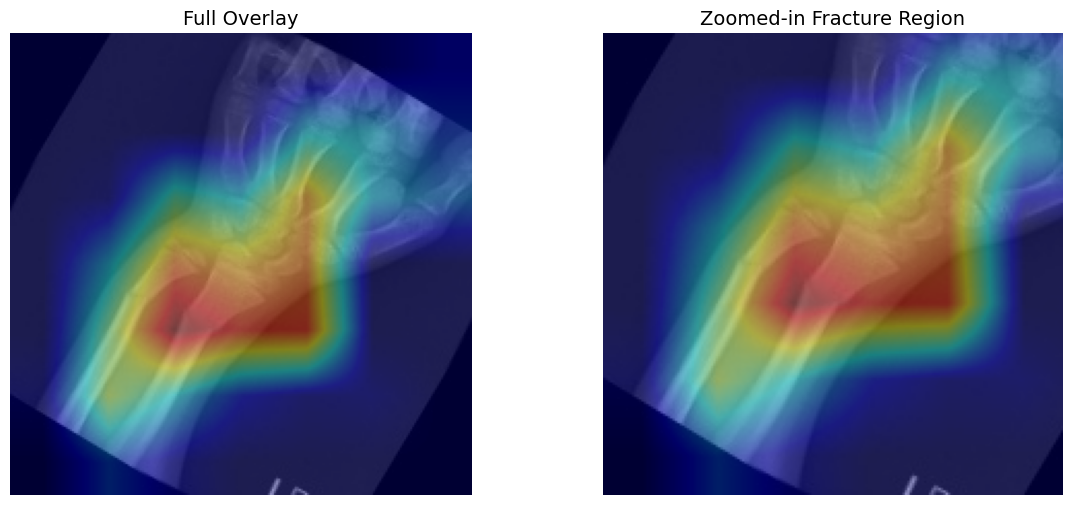

In [ ]:
zoomed_gradcam(imgs[5], model, grad_model)


In [ ]:
def multi_alpha_medical_panel(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))

    alphas = [0.2, 0.4, 0.6, 0.8]

    fig, axes = plt.subplots(1, 4, figsize=(20,5))

    for i, a in enumerate(alphas):
        overlay = overlay_heatmap_on_image(img, heatmap, alpha=a)
        axes[i].imshow(overlay)
        axes[i].set_title(f"α = {a}", fontsize=12)
        axes[i].axis('off')

    plt.suptitle("Multi-Alpha Medical Grad-CAM", fontsize=16)
    plt.show()


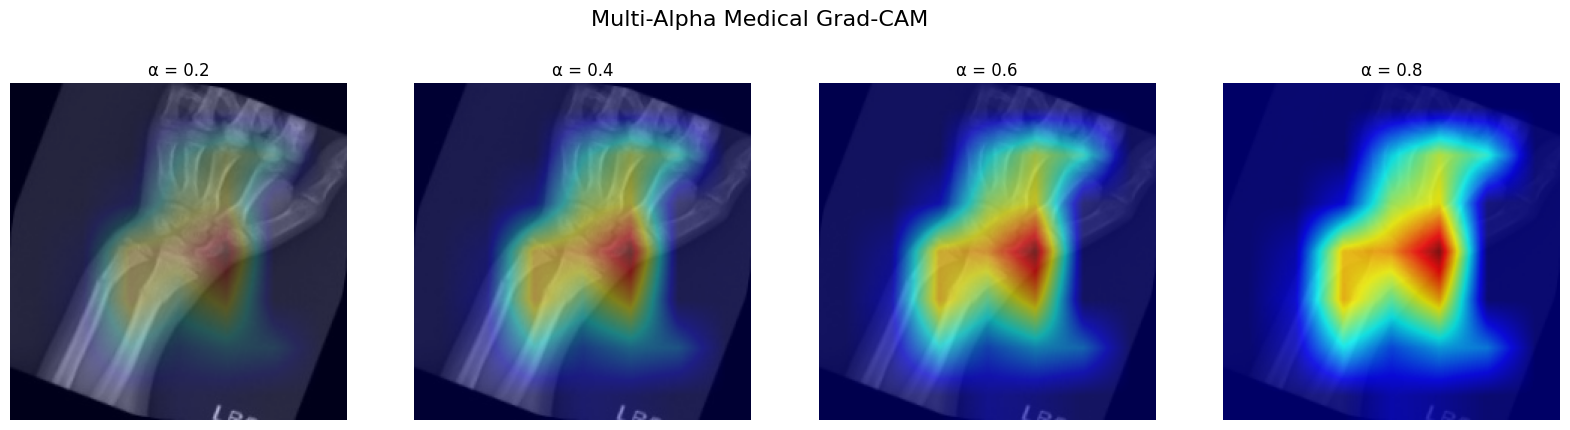

In [ ]:
multi_alpha_medical_panel(imgs[0], model, grad_model)


In [ ]:
def medical_tri_grid(img, model, grad_model):
    x = np.expand_dims(img, axis=0)
    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig, ax = plt.subplots(3,1, figsize=(8,12))

    data = [img, heatmap, overlay]
    titles = ["Original X-ray", "Grad-CAM Heatmap", "Overlay"]

    for i in range(3):
        ax[i].imshow(data[i], cmap="inferno" if i==1 else None)
        ax[i].set_title(titles[i], fontsize=14)
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()


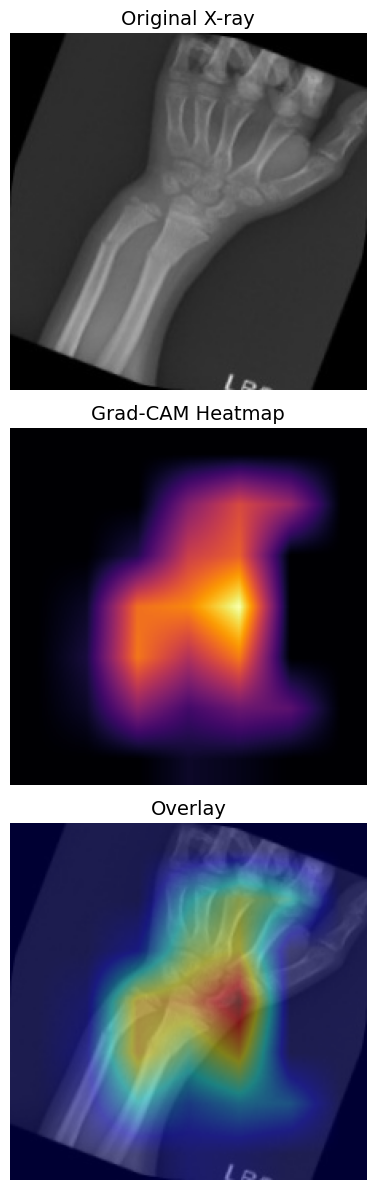

In [ ]:
medical_tri_grid(imgs[0], model, grad_model)


In [ ]:
def fusion_gradcam(img, model, grad_model):
    x = np.expand_dims(img, axis=0)

    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    gray = cv2.cvtColor(np.uint8(img*255), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 80, 160)

    fig, ax = plt.subplots(1,3, figsize=(18,6))
    ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(edges, cmap="gray"); ax[1].set_title("Canny Edge Map"); ax[1].axis("off")
    ax[2].imshow(overlay); ax[2].set_title("Edge-Aware Grad-CAM"); ax[2].axis("off")

    plt.show()


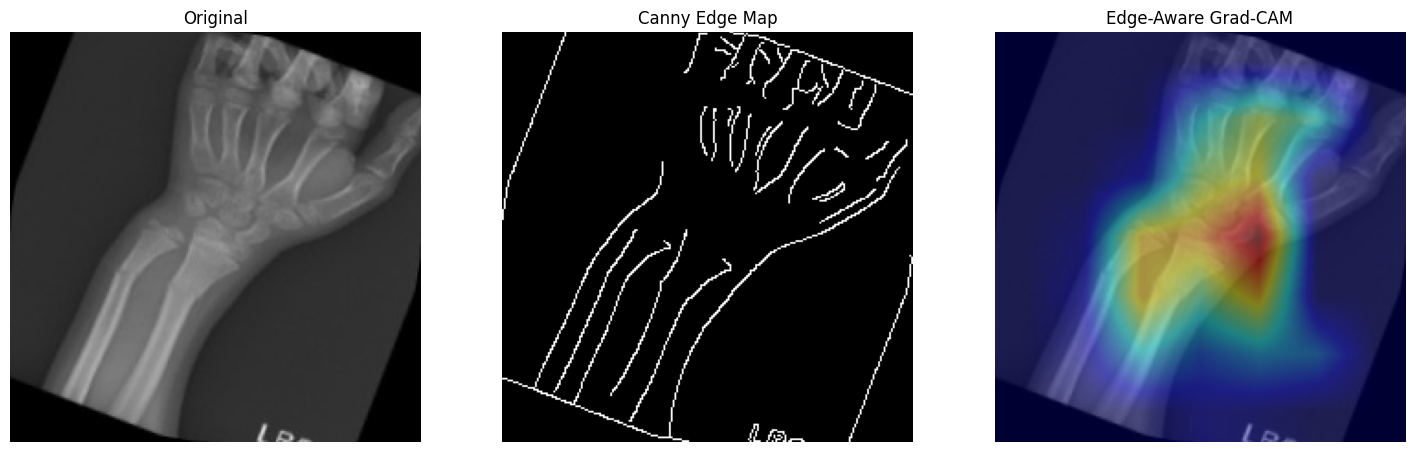

In [ ]:
fusion_gradcam(imgs[0], model, grad_model)


19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step


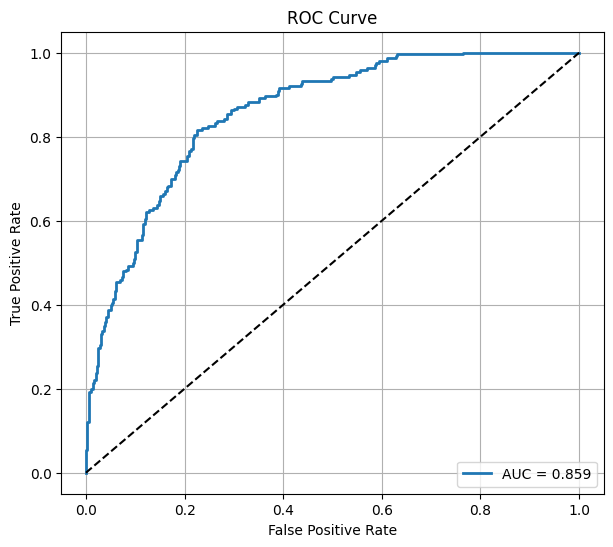

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, validation_generator):
    validation_generator.reset()
    y_true = validation_generator.classes
    y_pred = model.predict(validation_generator).ravel()

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_curve(model, validation_generator)


19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step


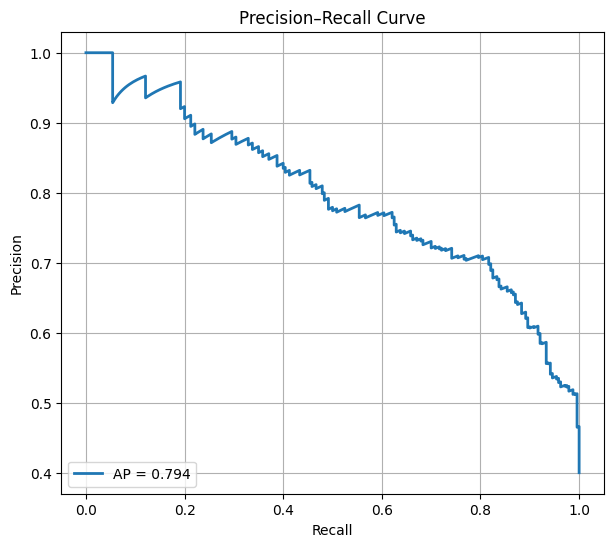

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall_curve(model, validation_generator):
    validation_generator.reset()
    y_true = validation_generator.classes
    y_pred = model.predict(validation_generator).ravel()

    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    AP = average_precision_score(y_true, y_pred)

    plt.figure(figsize=(7,6))
    plt.plot(recall, precision, lw=2, label=f"AP = {AP:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

plot_precision_recall_curve(model, validation_generator)


In [ ]:
def show_failure_cases(model, validation_generator, grad_model, max_cases=8):
    validation_generator.reset()
    y_true = validation_generator.classes
    y_pred = (model.predict(validation_generator) > 0.5).astype("int32").ravel()

    imgs, _ = next(validation_generator)
    failures = np.where(y_true != y_pred)[0]

    if len(failures) == 0:
        print("No failure cases found!")
        return

    failures = failures[:max_cases]

    plt.figure(figsize=(16,8))
    for i, idx in enumerate(failures):
        img = imgs[idx]
        x = np.expand_dims(img, axis=0)
        heatmap = compute_gradcam_heatmap(x, grad_model, (224,224))
        overlay = overlay_heatmap_on_image(img, heatmap)

        plt.subplot(2,4,i+1)
        plt.imshow(overlay)
        true_label = "Fractured" if y_true[idx]==1 else "Normal"
        pred_label = "Fractured" if y_pred[idx]==1 else "Normal"
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        plt.axis("off")

    plt.suptitle("Failure Case Diagnostics", fontsize=16)
    plt.tight_layout()
    plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step


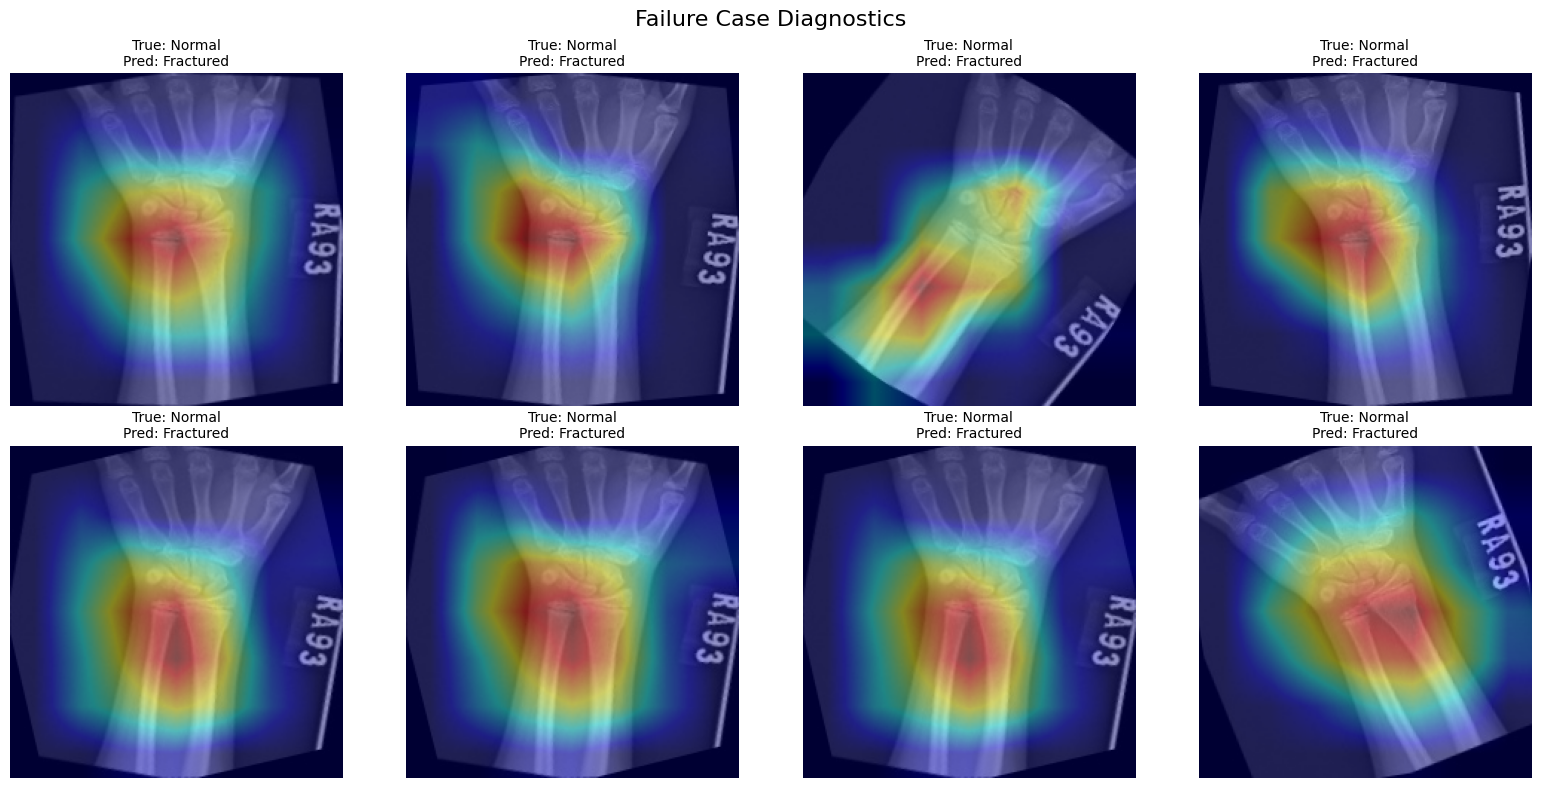

In [ ]:
show_failure_cases(model, validation_generator, grad_model)

In [ ]:
from google.colab import files
from PIL import Image

def upload_and_predict():
    uploaded = files.upload()
    for filename in uploaded.keys():
        img_path = filename

        img = Image.open(img_path).convert('RGB')
        img = img.resize((224,224))
        img_array = np.array(img)/255.0

        x = np.expand_dims(img_array, axis=0)

        # prediction
        prob = float(model.predict(x)[0][0])
        pred_label = "Fractured" if prob > 0.5 else "Normal"

        # Grad-CAM
        heatmap = compute_gradcam_heatmap(x, grad_model, (224,224))
        overlay = overlay_heatmap_on_image(img_array, heatmap)

        # Display
        plt.figure(figsize=(14,5))
        plt.subplot(1,3,1)
        plt.imshow(img_array)
        plt.title("Uploaded X-ray")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(heatmap, cmap='jet')
        plt.title("Grad-CAM Heatmap")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(overlay)
        plt.title(f"Prediction: {pred_label}\nConfidence: {prob:.3f}")
        plt.axis("off")

        plt.show()


Saving 10-rotated1-rotated2.jpg to 10-rotated1-rotated2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


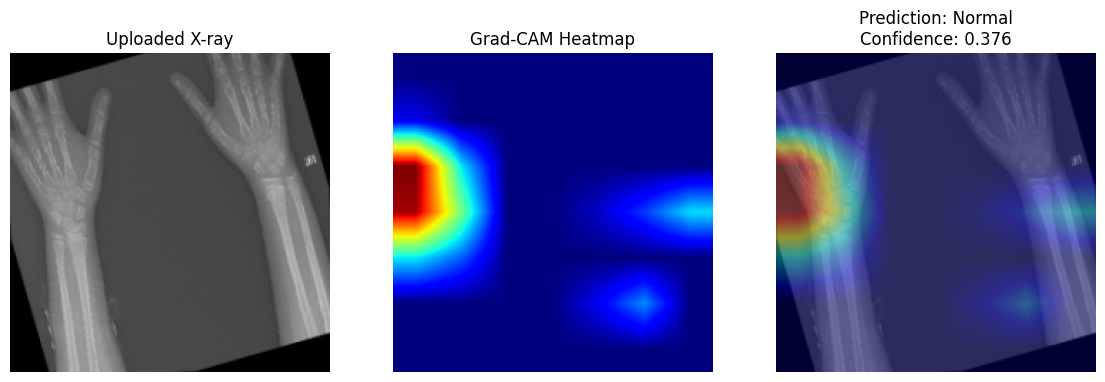

In [ ]:
upload_and_predict()


In [ ]:
model.save('/content/drive/MyDrive/fracture_model.keras')

In [ ]:
import os

save_dir = "/Users/akshatsharma/content/GradCAM_Outputs/"
os.makedirs(save_dir, exist_ok=True)

print("Saving all Grad-CAM outputs to:", save_dir)


Saving all Grad-CAM outputs to: /Users/akshatsharma/content/GradCAM_Outputs/


In [ ]:
import cv2
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

cv2.imwrite(f"{save_dir}/original_{timestamp}.png", cv2.cvtColor((img*255).astype('uint8'), cv2.COLOR_RGB2BGR))

cv2.imwrite(f"{save_dir}/heatmap_{timestamp}.png", cv2.applyColorMap((heatmap*255).astype('uint8'), cv2.COLORMAP_JET))

cv2.imwrite(f"{save_dir}/overlay_{timestamp}.png", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("Saved all outputs for this image.")


Saved all outputs for this image.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


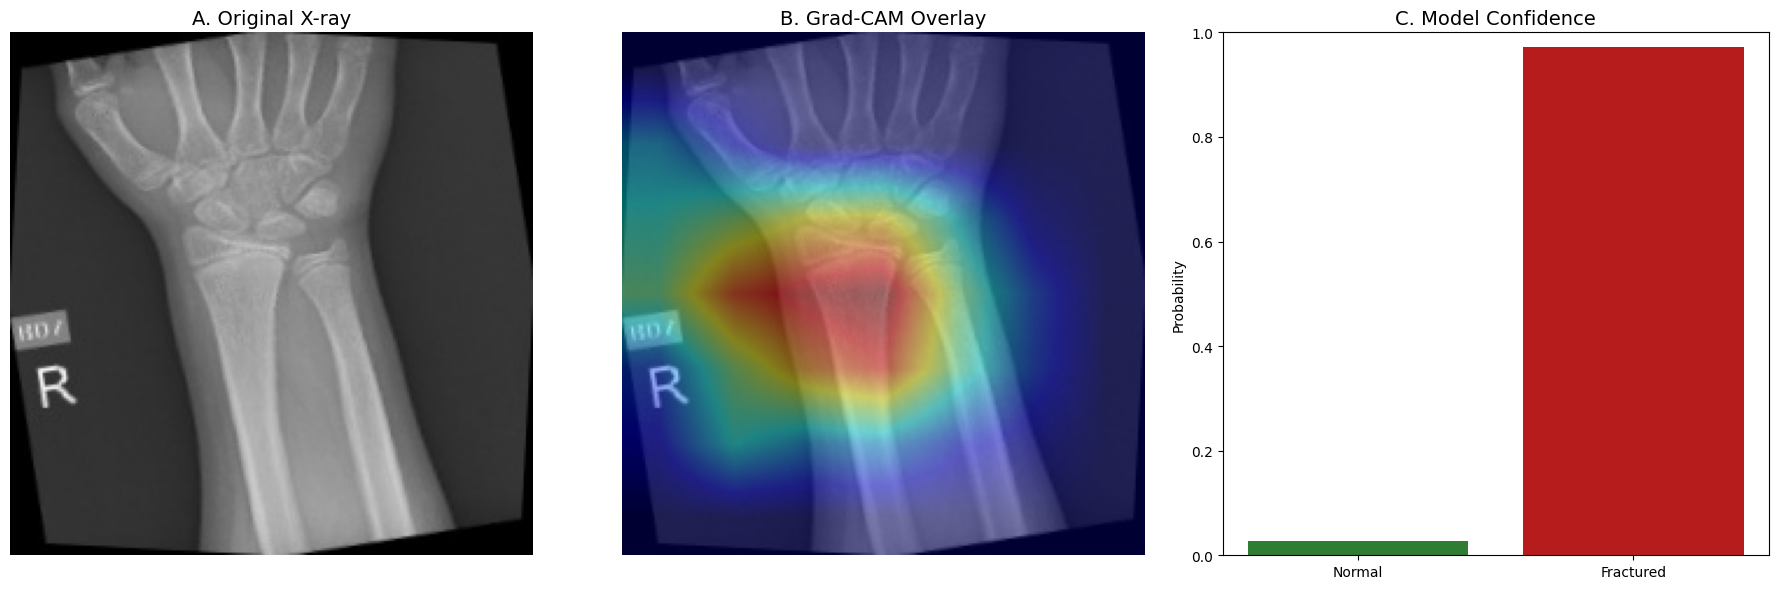

In [ ]:
medical_journal_composite(img, model, grad_model)


In [ ]:
import matplotlib.pyplot as plt

def medical_journal_composite_save(img, model, grad_model, save_path):
    x = np.expand_dims(img, axis=0)
    prob = float(model.predict(x)[0][0])

    heatmap = compute_gradcam_heatmap(x, grad_model, (img.shape[1], img.shape[0]))
    overlay = overlay_heatmap_on_image(img, heatmap)

    fig = plt.figure(figsize=(18,6), facecolor='white')

    ax1 = fig.add_subplot(1,3,1)
    ax1.imshow(img)
    ax1.set_title("A. Original X-ray")
    ax1.axis("off")

    ax2 = fig.add_subplot(1,3,2)
    ax2.imshow(overlay)
    ax2.set_title("B. Grad-CAM Overlay")
    ax2.axis("off")

    ax3 = fig.add_subplot(1,3,3)
    ax3.bar(["Normal", "Fractured"], [1-prob, prob], color=["#2E7D32","#B71C1C"])
    ax3.set_title("C. Model Confidence")
    ax3.set_ylim(0, 1)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    plt.close(fig)

save_path = f"{save_dir}/composite_panel_{timestamp}.png"
medical_journal_composite_save(img, model, grad_model, save_path)

print("Saved Medical Journal Composite panel at:", save_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Saved Medical Journal Composite panel at: /Users/akshatsharma/content/GradCAM_Outputs//composite_panel_20251120_014741.png


In [ ]:
model.save('/content/drive/MyDrive/fracture_model_final.h5')
print("Model saved successfully!")


Model saved successfully!


In [ ]:
def show_failure_cases(model, validation_generator, grad_model, max_cases=8):
    validation_generator.reset()
    y_true = validation_generator.classes
    y_pred = (model.predict(validation_generator) > 0.5).astype("int32").ravel()

    imgs, _ = next(validation_generator)
    failures = np.where(y_true != y_pred)[0]

    if len(failures) == 0:
        print("No failure cases found!")
        return

    failures = failures[:max_cases]

    plt.figure(figsize=(16,8))
    for i, idx in enumerate(failures):
        img = imgs[idx]
        x = np.expand_dims(img, axis=0)
        heatmap = compute_gradcam_heatmap(x, grad_model, (224,224))
        overlay = overlay_heatmap_on_image(img, heatmap)

        plt.subplot(2,4,i+1)
        plt.imshow(overlay)
        true_label = "Fractured" if y_true[idx]==1 else "Normal"
        pred_label = "Fractured" if y_pred[idx]==1 else "Normal"
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        plt.axis("off")

    plt.suptitle("Failure Case Diagnostics", fontsize=16)
    plt.tight_layout()
    plt.show()


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/fracture_model_final.h5')

print("Model loaded successfully!")

Model loaded successfully!
